In [1]:
pip install protobuf==3.20.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 13.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-monitoring 2.30.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-bigquery-connection 1.21.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-translate 3.26.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
googleapis-common-protos 1.74.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
wandb 0.25.1

In [110]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [109]:
import matplotlib.pyplot as plt
import tensorflow as tf
import random
import os
from glob import glob
from matplotlib import pyplot
import cv2
import pandas as pd
import numpy as np
import matplotlib.gridspec as gridspec
import seaborn as sns
import itertools
import sklearn
import scipy
import skimage
from skimage.transform import resize
import csv
from tqdm import tqdm
from sklearn import model_selection
from sklearn.model_selection import train_test_split, learning_curve, KFold, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix
import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from keras import models, layers, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from keras.layers import Activation, Dense, Dropout, Flatten
from keras.models import Model

In [108]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
train_path = '/content/drive/MyDrive/CONCRETE'

In [77]:
File=[]
for f in os.listdir(train_path):
    File += [f]

print(File)

['NORMAL', 'CRACK']


In [78]:
train_data = []
mapping={'Tumor':1, 'Stroma':0}
count=0
for f in os.listdir(train_path):
    path = os.path.join(train_path, f)
    for im in os.listdir(path):
        img = load_img(os.path.join(path, im), color_mode='rgb', target_size=(128,128))
        img = img_to_array(img)
        img = img / 255.0
        train_data.append([img, count])
    count=count+1

In [111]:
train_images, train_labels = zip(*train_data)

In [117]:
train_labels = to_categorical(train_labels)
train_images = np.array(train_images)
train_labels = np.array(train_labels)
if len(train_labels.shape) == 3:
    train_labels = train_labels.reshape(train_labels.shape[0], -1)
print(train_images.shape)
print(train_labels.shape)

(1000, 128, 128, 3)
(1000, 2)


In [80]:
train_images = train_images.reshape(-1,128,128,3)

In [81]:
X_train, X_test, y_train, y_test = train_test_split(train_images,train_labels, test_size=0.1,random_state=44)

In [82]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(900, 128, 128, 3)
(100, 128, 128, 3)
(900, 2, 2)
(100, 2, 2)


In [83]:
data_aug = ImageDataGenerator(horizontal_flip=True, vertical_flip=True, rotation_range=20, zoom_range=0.2, width_shift_range=0.2, height_shift_range=0.2, shear_range=0.1, fill_mode="nearest")

In [123]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
model1 = MobileNet(input_shape=(128,128,3), include_top=False, weights='imagenet')
model1.trainable = True
for layer in model1.layers[:-4]:
    layer.trainable = False
print("MobileNet Base loaded.")

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
MobileNet Base loaded.


In [88]:
x = tf.keras.layers.GlobalAveragePooling2D()(model1.output)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
out = tf.keras.layers.Dense(2, activation='softmax')(x)
model = tf.keras.Model(inputs=model1.input, outputs=out)
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), metrics=['accuracy'])
model.summary()

Model: "functional_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_30 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 14,879,170 (56.76 MB)

 Trainable params: 7,243,906 (27.63 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [124]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def create_proxy_model(lr, dropout):
    base_model = tf.keras.applications.MobileNet(input_shape=(128,128,3), include_top=False, weights='imagenet', pooling='max')
    base_model.trainable = False
    x = layers.Dense(128, activation='relu')(base_model.output)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(2, activation='softmax')(x)
    model = models.Model(inputs=base_model.input, outputs=out)
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def objective_function(params, X_tr, y_tr, X_val, y_val):
    lr, dropout, batch_size = params
    batch_size = int(np.round(batch_size))
    model = create_proxy_model(lr, dropout)
    hist = model.fit(X_tr, y_tr, batch_size=batch_size, epochs=2, validation_data=(X_val, y_val), verbose=0)
    val_acc = max(hist.history['val_accuracy'])
    return -val_acc

def marine_predator_algorithm(X_tr, y_tr, X_val, y_val, n_predators=5, max_iter=3):
    lb = np.array([1e-5, 0.3, 8])
    ub = np.array([1e-3, 0.5, 16])
    dim = 3
    prey = lb + (ub - lb) * np.random.rand(n_predators, dim)
    fitness = np.array([objective_function(p, X_tr, y_tr, X_val, y_val) for p in prey])
    best_idx = np.argmin(fitness)
    elite = prey[best_idx].copy()
    best_fit = fitness[best_idx]
    for t in range(max_iter):
        if t < max_iter / 3:
            stepsize = np.random.standard_normal((n_predators, dim))
            prey = prey + 0.5 * np.random.rand() * stepsize * (elite - prey)
        elif t < 2 * max_iter / 3:
            for i in range(n_predators // 2):
                stepsize = np.random.standard_normal(dim)
                prey[i] = elite + 0.5 * np.random.rand() * stepsize * (elite - prey[i])
            for i in range(n_predators // 2, n_predators):
                prey[i] = elite + 0.5 * np.random.rand() * (elite - prey[i])
        else:
            stepsize = np.random.standard_normal((n_predators, dim))
            prey = elite + 0.5 * np.random.rand() * stepsize * (elite - prey)
        prey = np.clip(prey, lb, ub)
        for i in range(n_predators):
            new_fit = objective_function(prey[i], X_tr, y_tr, X_val, y_val)
            if new_fit < fitness[i]:
                fitness[i] = new_fit
                if new_fit < best_fit:
                    best_fit = new_fit
                    elite = prey[i].copy()
        print(f"Iteration {t+1}: Best Val Acc = {-best_fit:.4f}")
    return elite, -best_fit

def fix_labels(y):
    if len(y.shape) == 3:
        return y[:, 0, :]
    return y

y_train_fixed = fix_labels(y_train)
y_test_fixed = fix_labels(y_test)

best_params, best_acc = marine_predator_algorithm(X_train, y_train_fixed, X_test, y_test_fixed)
opt_lr, opt_dropout, opt_batch_size = best_params
opt_batch_size = int(np.round(opt_batch_size))

Iteration 1: Best Val Acc = 1.0000
Iteration 2: Best Val Acc = 1.0000
Iteration 3: Best Val Acc = 1.0000


In [126]:
tf.keras.backend.clear_session()
inp = model1.input
x = tf.keras.layers.GlobalAveragePooling2D()(model1.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(opt_dropout)(x)
out = tf.keras.layers.Dense(2, activation='softmax')(x)
model = tf.keras.Model(inputs=inp, outputs=out)
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=opt_lr), metrics=['accuracy'])

In [127]:
history = model.fit(
    data_aug.flow(X_train, y_train_fixed, batch_size=opt_batch_size),
    validation_data=(X_test, y_test_fixed),
    epochs=50
)

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 28s 264ms/step - accuracy: 0.9567 - loss: 0.1301 - val_accuracy: 0.9900 - val_loss: 0.0378
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.9878 - loss: 0.0282 - val_accuracy: 1.0000 - val_loss: 2.6851e-05
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.9878 - loss: 0.0457 - val_accuracy: 1.0000 - val_loss: 2.6893e-06
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9856 - loss: 0.0499 - val_accuracy: 1.0000 - val_loss: 6.9736e-07
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9911 - loss: 0.0260 - val_accuracy: 1.0000 - val_loss: 4.7585e-04
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.9833 - loss: 0.0582 - val_accuracy: 1.0000 - val_loss: 1.0311e-06
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.9911 - loss: 0.0343 - val_accuracy: 1.0000 - val_loss: 2.7202e-05
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9844 - loss: 0.0533

In [129]:
y_pred=model.predict(X_test)
pred = np.argmax(y_pred,axis=1)
ground = np.argmax(y_test_fixed,axis=1)
from sklearn.metrics import classification_report
print(classification_report(ground,pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        55

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [130]:
# Viewing Model Summary
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_47 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 64, 64, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 64, 64, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 65, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 32, 32, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 32, 32, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 32, 32, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 32, 32, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 5,724,488 (21.84 MB)

 Trainable params: 1,182,082 (4.51 MB)

 Non-trainable params: 2,178,240 (8.31 MB)

 Optimizer params: 2,364,166 (9.02 MB)

None


In [131]:
t=list(model.layers)
conv_index=[]
for i in range(len(t)):
  layer=t[i]
  if 'conv' in layer.name:
    conv_index.append(i)
print(conv_index)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85]


In [132]:
for i in conv_index:
  layer=model.layers[i]
  print("layer name is :{}            output Shape is : {}".format(layer.name,layer.output.shape))

layer name is :conv1            output Shape is : (None, 64, 64, 32)
layer name is :conv1_bn            output Shape is : (None, 64, 64, 32)
layer name is :conv1_relu            output Shape is : (None, 64, 64, 32)
layer name is :conv_dw_1            output Shape is : (None, 64, 64, 32)
layer name is :conv_dw_1_bn            output Shape is : (None, 64, 64, 32)
layer name is :conv_dw_1_relu            output Shape is : (None, 64, 64, 32)
layer name is :conv_pw_1            output Shape is : (None, 64, 64, 64)
layer name is :conv_pw_1_bn            output Shape is : (None, 64, 64, 64)
layer name is :conv_pw_1_relu            output Shape is : (None, 64, 64, 64)
layer name is :conv_pad_2            output Shape is : (None, 65, 65, 64)
layer name is :conv_dw_2            output Shape is : (None, 32, 32, 64)
layer name is :conv_dw_2_bn            output Shape is : (None, 32, 32, 64)
layer name is :conv_dw_2_relu            output Shape is : (None, 32, 32, 64)
layer name is :conv_pw_2      

In [133]:
M_conv_1=Model(inputs=model.inputs, outputs=model.layers[2].output)
M_conv_1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_47 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 64, 64, 32)     │           128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 992 (3.88 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 992 (3.88 KB)

In [134]:
img = load_img("/content/drive/MyDrive/CONCRETE/CRACK/C (10).jpg",target_size=(128,128))
img = img_to_array(img)
img = img / 255.0
img = np.expand_dims(img, axis=0)
feature_maps=M_conv_1.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step


In [135]:
M_conv_1=Model(inputs=model.inputs, outputs=model.layers[5].output)
M_conv_1.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_47 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 64, 64, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,408 (5.50 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,408 (5.50 KB)

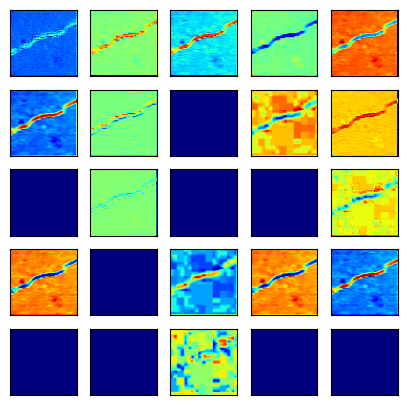

In [136]:
from matplotlib import pyplot
square=5
ix=1
ax=pyplot.figure(figsize=(5,5))
for i in range(square):
  for j in range(square):
    ax=pyplot.subplot(square,square,ix)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    pyplot.imshow(feature_maps[0,:,:,ix-1],aspect='auto',cmap="jet")
    ix+=1
pyplot.savefig("CO1.tiff",format="tiff")
pyplot.show()

In [137]:
M_conv_1=Model(inputs=model.inputs, outputs=model.layers[10].output)
M_conv_1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_47 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 64, 64, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 64, 64, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 65, 65, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,712 (14.50 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,712 (14.50 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


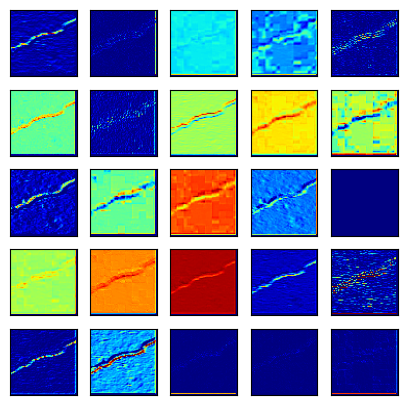

In [138]:
feature_maps=M_conv_1.predict(img)
from matplotlib import pyplot
square=5
ix=1
ax=pyplot.figure(figsize=(5,5))
for i in range(square):
  for j in range(square):
    ax=pyplot.subplot(square,square,ix)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    pyplot.imshow(feature_maps[0,:,:,ix-1],aspect='auto',cmap="jet")
    ix+=1
pyplot.savefig("CO1.tiff",format="tiff")
pyplot.show()

In [139]:
M_conv_1=Model(inputs=model.inputs, outputs=model.layers[15].output)
M_conv_1.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_47 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 64, 64, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 64, 64, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 65, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 32, 32, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 32, 32, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,248 (51.75 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 13,248 (51.75 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


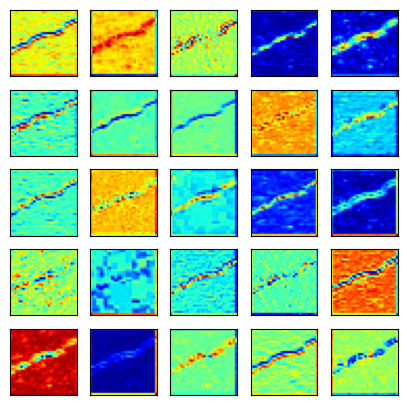

In [140]:
feature_maps=M_conv_1.predict(img)
from matplotlib import pyplot
square=5
ix=1
ax=pyplot.figure(figsize=(5,5))
for i in range(square):
  for j in range(square):
    ax=pyplot.subplot(square,square,ix)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    pyplot.imshow(feature_maps[0,:,:,ix-1],aspect='auto',cmap="jet")
    ix+=1
pyplot.savefig("CO1.tiff",format="tiff")
pyplot.show()

In [141]:
M_conv_1=Model(inputs=model.inputs, outputs=model.layers[20].output)
M_conv_1.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_47 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 64, 64, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 64, 64, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 65, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 32, 32, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 32, 32, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 32, 32, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 32, 32, 128)    │        16,384 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,296 (122.25 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 31,296 (122.25 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


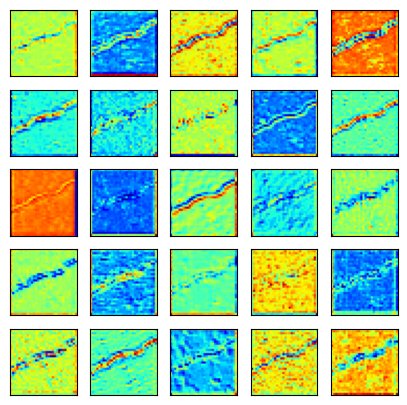

In [142]:
feature_maps=M_conv_1.predict(img)
from matplotlib import pyplot
square=5
ix=1
ax=pyplot.figure(figsize=(5,5))
for i in range(square):
  for j in range(square):
    ax=pyplot.subplot(square,square,ix)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    pyplot.imshow(feature_maps[0,:,:,ix-1],aspect='auto',cmap="jet")
    ix+=1
pyplot.savefig("CO1.tiff",format="tiff")
pyplot.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
Reducing dimensions...


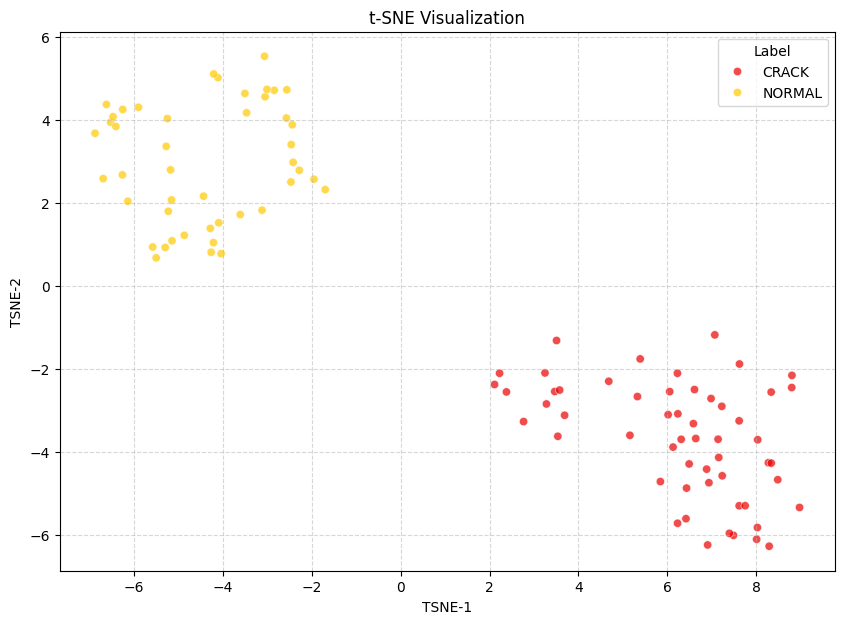

In [146]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

feature_extractor = tf.keras.Model(inputs=model.input, outputs=model.get_layer('conv_pw_13').output)
X_test_features = feature_extractor.predict(X_test)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_test_features_flat = X_test_features.reshape(X_test_features.shape[0], -1)

print("Reducing dimensions...")
X_test_2d = tsne.fit_transform(X_test_features_flat)

y_test_labels = [File[i] for i in np.argmax(y_test_fixed, axis=1)]

df_tsne = pd.DataFrame({
    'TSNE-1': X_test_2d[:, 0],
    'TSNE-2': X_test_2d[:, 1],
    'Label': y_test_labels
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_tsne, x='TSNE-1', y='TSNE-2', hue='Label', palette='hot', alpha=0.7)
plt.title('t-SNE Visualization')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

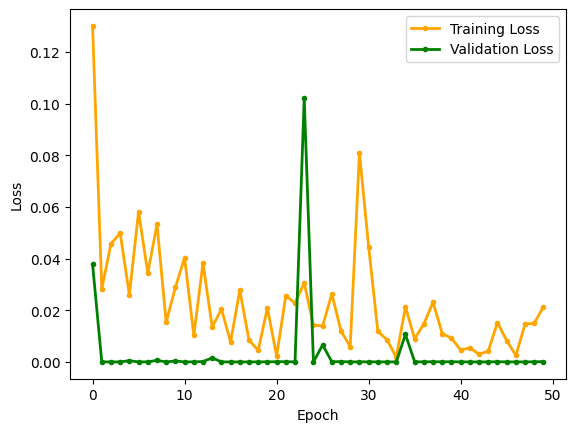

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [147]:
epochs = range(50)
plt.plot(epochs, history.history['loss'], 'orange', marker=".", label='Training Loss', linewidth=2)
plt.plot(epochs, history.history['val_loss'], 'g', marker=".", label='Validation Loss', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Loss');
plt.legend(loc=1)
plt.figure()
plt.show()
pyplot.savefig("Loss.tiff",format="tiff")

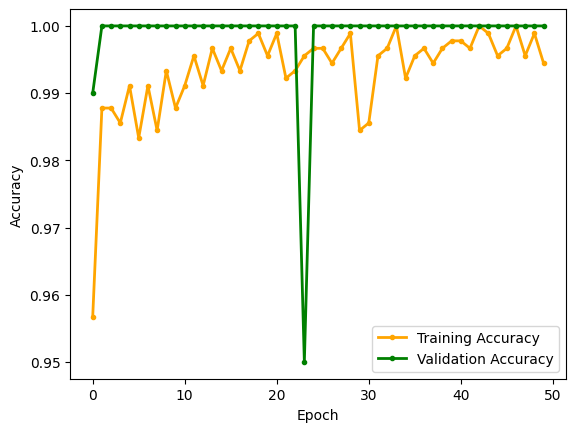

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [148]:
epochs = range(50)
plt.plot(epochs, history.history['accuracy'], 'orange', marker=".", label='Training Accuracy', linewidth=2)
plt.plot(epochs, history.history['val_accuracy'], 'g', marker=".", label='Validation Accuracy', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Accuracy');
plt.legend(loc=4)
plt.figure()
plt.show()
pyplot.savefig("ACC.tiff",format="tiff")

In [149]:
y_test_arg=np.argmax(y_test,axis=1)
Y_pred = np.argmax(model.predict(X_test),axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [151]:
y_true = np.argmax(y_test_fixed, axis=1)
accuracy = accuracy_score(y_true, Y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 1.0


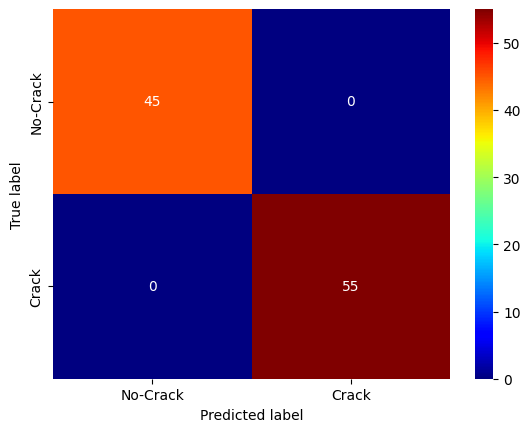

In [153]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

y_true = np.argmax(y_test_fixed, axis=1)
cm = confusion_matrix(y_true, Y_pred)
f = sns.heatmap(cm, annot=True, fmt='d', cmap="jet")
f.set_xlabel('Predicted label')
f.set_ylabel('True label')
f.xaxis.set_ticklabels(['No-Crack', 'Crack'])
f.yaxis.set_ticklabels(['No-Crack', 'Crack'])
plt.savefig("CM.tiff", format="tiff")
plt.show()

In [154]:
TP = cm[1][1]
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
print('True Positives:', TP)
print('True Negatives:', TN)
print('False Positives:', FP)
print('False Negatives:', FN)

True Positives: 55
True Negatives: 45
False Positives: 0
False Negatives: 0


In [155]:
conf_accuracy = (float (TP+TN) / float(TP + TN + FP + FN))
conf_misclassification = 1- conf_accuracy
conf_sensitivity = (TP / float(TP + FN))
conf_specificity = (TN / float(TN + FP))
conf_precision = (TN / float(TN + FP))
conf_NPV = (TN / float(TN + FN))
conf_f1 = 2 * ((conf_precision * conf_sensitivity) / (conf_precision + conf_sensitivity))
print('-'*50)
print(f'Accuracy: {round(conf_accuracy,4)}')
print(f'Mis-Classification: {round(conf_misclassification,4)}')
print(f'Sensitivity: {round(conf_sensitivity,4)}')
print(f'Specificity: {round(conf_specificity,4)}')
print(f'Precision: {round(conf_precision,4)}')
print(f'NPV: {round(conf_NPV,4)}')
print(f'f_1 Score: {round(conf_f1,2)}')

--------------------------------------------------
Accuracy: 1.0
Mis-Classification: 0.0
Sensitivity: 1.0
Specificity: 1.0
Precision: 1.0
NPV: 1.0
f_1 Score: 1.0


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


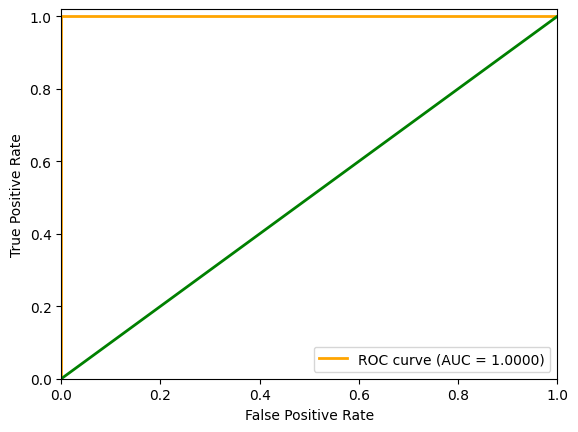

--------------------------------------------------
Accuracy: 1.0
Mis-Classification: 0.0
Sensitivity: 1.0
Specificity: 1.0
Precision: 1.0
NPV: 1.0
f_1 Score: 1.0


In [157]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

conf_accuracy = (float(TP + TN) / float(TP + TN + FP + FN))
conf_misclassification = 1 - conf_accuracy
conf_sensitivity = (TP / float(TP + FN))
conf_specificity = (TN / float(TN + FP))
conf_precision = (TN / float(TN + FP))
conf_NPV = (TN / float(TN + FN))
conf_f1 = 2 * ((conf_precision * conf_sensitivity) / (conf_precision + conf_sensitivity))

y_true_1d = np.argmax(y_test_fixed, axis=1)
y_scores = model.predict(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_true_1d, y_scores)
auc = roc_auc_score(y_true_1d, y_scores)

plt.figure()
plt.plot(fpr, tpr, 'orange', label='ROC curve (AUC = %0.4f)' % auc, linewidth=2)
plt.plot([0, 1], [0, 1], 'g', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

print('-' * 50)
print(f'Accuracy: {round(conf_accuracy, 4)}')
print(f'Mis-Classification: {round(conf_misclassification, 4)}')
print(f'Sensitivity: {round(conf_sensitivity, 4)}')
print(f'Specificity: {round(conf_specificity, 4)}')
print(f'Precision: {round(conf_precision, 4)}')
print(f'NPV: {round(conf_NPV, 4)}')
print(f'f_1 Score: {round(conf_f1, 2)}')